# Financial Stress Index & Credit Pricing System
## Notebook 01 — Data Understanding

Objective:
- Understand Lending Club accepted loan data
- Identify decision-time financial behavior features
- Build a clean foundation for Financial Stress Index (FSI)

Important:
- No modeling in this notebook
- No feature engineering yet
- Only understanding and validation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Used

We use only **accepted loans** for modeling and pricing because:
- Interest rate exists only for approved loans
- Pricing decisions are observable only here

Rejected loans will be used later only for sanity checks.


In [2]:
DATA_PATH = "../data/raw/accepted.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
df.shape


(2260701, 151)

### Initial Data Inspection

We inspect:
- Column types
- Missing values
- Scale of numeric features


In [3]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,15046.931228,9190.245488,500.00,8000.00,12900.00,20000.0000,40000.00
funded_amnt,2260668.0,15041.664057,9188.413022,500.00,8000.00,12875.00,20000.0000,40000.00
funded_amnt_inv,2260668.0,15023.437745,9192.331679,0.00,8000.00,12800.00,20000.0000,40000.00
int_rate,2260668.0,13.092829,4.832138,5.31,9.49,12.62,15.9900,30.99
...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,10917.0,11636.883942,7625.988281,55.73,5627.00,10028.39,16151.8900,40306.41
hardship_last_payment_amount,10917.0,193.994321,198.629496,0.01,44.44,133.16,284.1900,1407.86
settlement_amount,34246.0,5010.664267,3693.122590,44.21,2208.00,4146.11,6850.1725,33601.00
settlement_percentage,34246.0,47.780365,7.311822,0.20,45.00,45.00,50.0000,521.35


### Why We Cannot Use All Columns

Many columns:
- Are post-loan outcomes
- Leak future information
- Are irrelevant at decision time

Fintech models must use **only information available at loan approval time**.

In [6]:
selected_columns = [
    "annual_inc",
    "emp_length",
    "loan_amnt",
    "term",
    "dti",
    "revol_util",
    "delinq_2yrs",
    "inq_last_6mths",
    "int_rate",
    "issue_d"
]

df = df[selected_columns]
df.head()

,annual_inc,emp_length,loan_amnt,term,dti,revol_util,delinq_2yrs,inq_last_6mths,int_rate,issue_d
0,55000.0,10+ years,3600.0,36 months,5.91,29.7,0.0,1.0,13.99,Dec-2015
1,65000.0,10+ years,24700.0,36 months,16.06,19.2,1.0,4.0,11.99,Dec-2015
2,63000.0,10+ years,20000.0,60 months,10.78,56.2,0.0,0.0,10.78,Dec-2015
3,110000.0,10+ years,35000.0,60 months,17.06,11.6,0.0,0.0,14.85,Dec-2015
4,104433.0,3 years,10400.0,60 months,25.37,64.5,1.0,3.0,22.45,Dec-2015


### Missing Value Analysis

In credit risk:
- Aggressive imputation is dangerous
- We prefer conservative cleaning

In [7]:
(df.isna().mean() * 100).sort_values(ascending=False)

emp_length        6.499754
revol_util        0.081170
dti               0.077144
inq_last_6mths    0.002787
delinq_2yrs       0.002743
annual_inc        0.001637
loan_amnt         0.001460
term              0.001460
int_rate          0.001460
issue_d           0.001460
dtype: float64

### Distribution Analysis

Understanding distributions helps:
- Identify skewness
- Detect outliers
- Decide normalization strategy

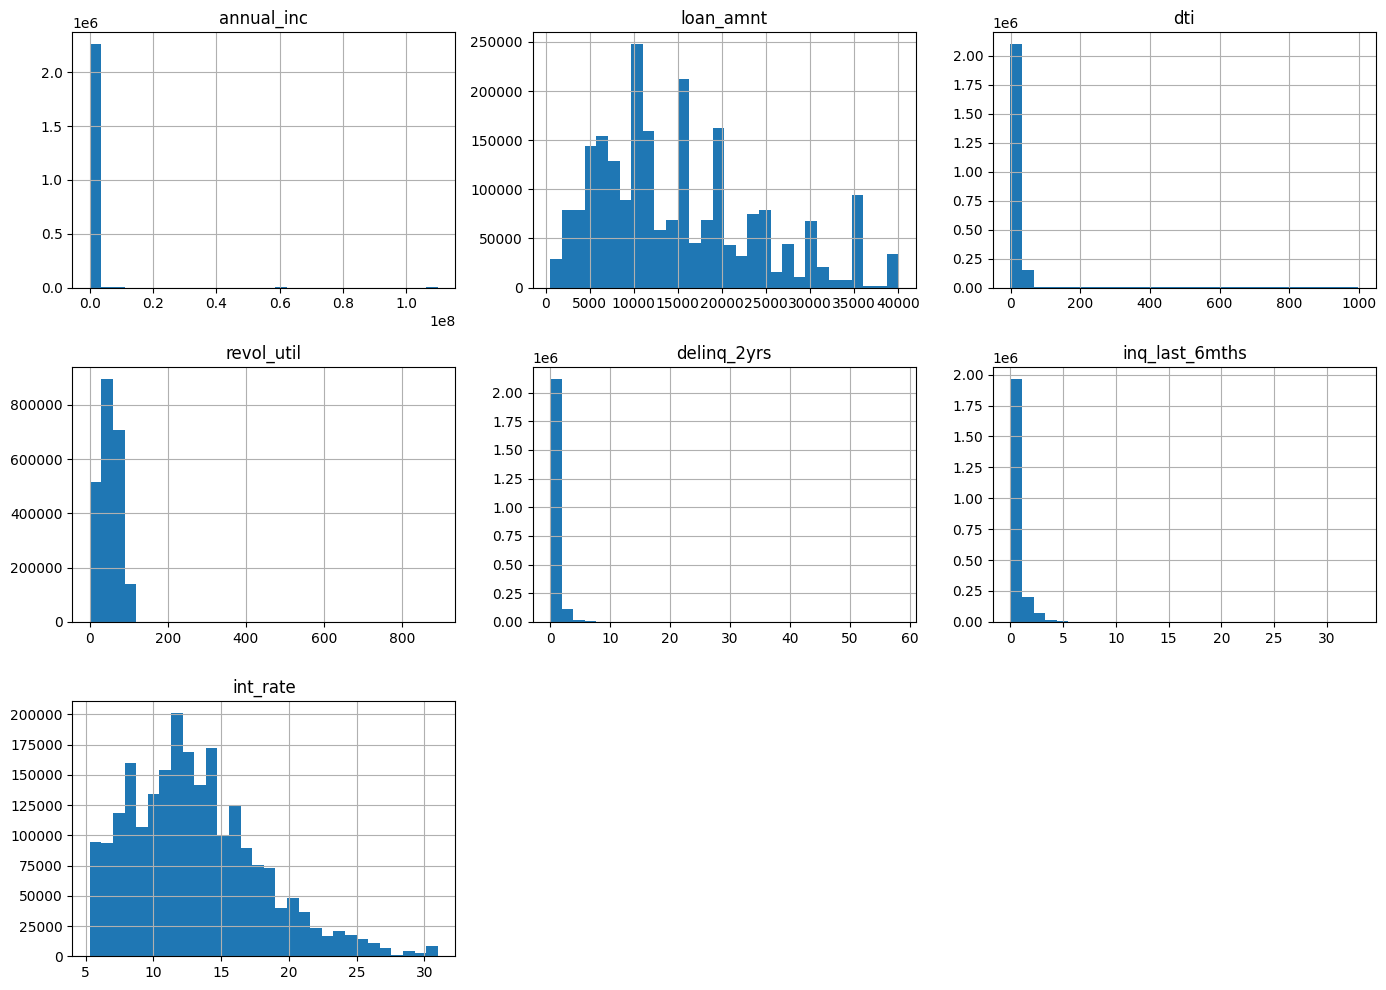

In [8]:
numeric_cols = [
    "annual_inc",
    "loan_amnt",
    "dti",
    "revol_util",
    "delinq_2yrs",
    "inq_last_6mths",
    "int_rate"
]

df[numeric_cols].hist(bins=30, figsize=(14,10))
plt.tight_layout()

Key Observations:

1. Income is highly right-skewed
2. Credit utilization is capped and very informative
3. Delinquencies are sparse but high-impact
4. Interest rate is non-linear and risk-driven

These insights justify why we need an engineered Financial Stress Index.

### Time Awareness

Credit risk models must respect time.
Random splits cause data leakage.

In [9]:
df["issue_d"] = pd.to_datetime(df["issue_d"])
df["issue_d"].min(), df["issue_d"].max()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18680\2619914041.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["issue_d"] = pd.to_datetime(df["issue_d"])


(Timestamp('2007-06-01 00:00:00'), Timestamp('2018-12-01 00:00:00'))

### Saving Clean Base Dataset

This dataset will be used in later notebooks for:
- Feature engineering
- FSI design
- Regression modeling

In [10]:
OUTPUT_PATH = "../data/processed/modeling_dataset.csv"
df.to_csv(OUTPUT_PATH, index=False)

In [11]:
df.shape

(2260701, 10)

### Notebook 01 Summary

- Understood Lending Club accepted loan data
- Selected only decision-time features
- Avoided target leakage
- Preserved time information
- Saved clean base dataset

Next Notebook:
02_feature_engineering.ipynb